In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

from tqdm import tqdm

import os
import random
import copy

import torch.nn as nn
from torch_geometric.loader import DataLoader
from torch.nn import Linear, Sequential, LayerNorm, ReLU, LeakyReLU, Sigmoid, Tanh
from torch_geometric.nn.conv import MessagePassing
from torch.optim.lr_scheduler import CosineAnnealingLR
import torch_scatter
from torch.autograd import Variable

import torch
import torch.nn.functional as F 

In [2]:
torch.__version__

'2.7.1+cu128'

In [3]:
#Set seeds w/ a prime number :)
seednum = 31
torch.manual_seed(seednum)
random.seed(seednum)
np.random.seed(seednum)

#Scalers
minmax = False
standardize = True

#Activations
activation = ReLU()

In [4]:
#GPU/CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [5]:
#Load prepared data
datadir = 'GNN_DataPrep\\data_GNN\\'

# Node input data x,y,xinv,yinv,edgedist,xdist,ydist
# Edge data dx, dy, length
# Node output data 'S11', 'S22', 'S12', 'Mises'

#Number of non-categorical inputs to normalize/standardize
xdimnormalize = 7 

pt_data=[]

files = os.listdir(datadir)
for file in tqdm(files):
    if file.endswith('.pt'):
        fname = os.path.join(datadir, file)
        data = torch.load(fname, weights_only=False)
        pt_data.append(data)

100%|██████████| 3966/3966 [00:00<00:00, 6752.30it/s]


In [6]:
data, data.x[:5,:], data.edge_attr[5,:], data.y[:5,:]

(Data(x=[320, 11], edge_index=[2, 2272], edge_attr=[2272, 3], y=[320, 4]),
 tensor([[1.4560, 4.2190, 3.6289, 1.7056, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          1.0000, 0.0000],
         [1.0971, 5.1466, 3.9878, 0.7780, 0.6360, 0.6213, 0.1360, 0.0000, 0.0000,
          0.0000, 1.0000],
         [0.0000, 5.0409, 5.0849, 0.8837, 0.0000, 0.0000, 0.0000, 1.0000, 0.0000,
          0.0000, 0.0000],
         [0.0000, 3.5970, 5.0849, 2.3276, 0.0000, 0.0000, 0.0000, 1.0000, 0.0000,
          0.0000, 0.0000],
         [1.2644, 3.7876, 3.8205, 2.1370, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          1.0000, 0.0000]], dtype=torch.float64),
 tensor([ 0.0595, -0.2608,  0.2675], dtype=torch.float64),
 tensor([[   4.2659,  -90.5274,  -55.3584,  134.0204],
         [ 212.6530,   22.2874, -184.7340,  378.6288],
         [ 216.9374,   66.2698, -157.0381,  333.2571],
         [ 258.0488,   75.9455, -168.6935,  371.6633],
         [  54.1804,  268.5527, -132.1380,  336.1394]], dtype=torch.float64))

In [8]:
#Shuffle data
random.shuffle(pt_data)

In [9]:
#Normalize
if standardize:
    #Vertices - batch.x
    inv_mean = np.zeros(xdimnormalize)
    inv_std = np.zeros(xdimnormalize)
    inv_count = np.zeros(xdimnormalize)

    #edges
    ine_mean = np.zeros(data.edge_attr.shape[1])
    ine_std = np.zeros(data.edge_attr.shape[1])
    ine_count = np.zeros(data.edge_attr.shape[1])

    #Outputs
    out_mean = np.zeros(data.y.shape[1])
    out_std = np.zeros(data.y.shape[1])
    out_count = np.zeros(data.y.shape[1])

In [10]:
#Calculate means
if standardize:
    for _, batch in enumerate(pt_data):
        for i in range(xdimnormalize):
            #vertices
            summation = batch.x[:,i].sum()
            count = len(batch.x[:,i])
            inv_mean[i] += summation
            inv_count[i] += count

        for i in range(data.edge_attr.shape[1]):
            #edges
            summation = batch.edge_attr[:,i].sum()
            count = len(batch.edge_attr[:,i])
            ine_mean[i] += summation
            ine_count[i] += count

        for i in range(data.y.shape[1]):
            #stress
            summation = batch.y[:,i].sum()
            count = len(batch.y[:,i])
            out_mean[i] += summation
            out_count[i] += count

    #means
    inv_mean = inv_mean / inv_count
    ine_mean = ine_mean / ine_count
    out_mean = out_mean / out_count

In [11]:
if standardize:
    print(inv_mean, ine_mean, out_mean)

[2.79256868 2.18011393 3.9120145  2.79617359 0.43955792 0.00437867
 0.00482554] [-2.26468415e-20  2.68424669e-20  3.47167841e-01] [  59.16085507   63.53372978 -197.53394835  753.39816865]


In [12]:
#StDev.
if standardize:
    for _, batch in enumerate(pt_data):
        for i in range(xdimnormalize):
            #vertices
            summation = ((batch.x[:,i] - inv_mean[i])**2).sum()
            count = len(batch.x[:,i])
            inv_std[i] += summation
            inv_count[i] += count

        for i in range(data.edge_attr.shape[1]):
            #edges
            summation = ((batch.edge_attr[:,i] - ine_mean[i])**2).sum()
            count = len(batch.edge_attr[:,i])
            ine_std[i] += summation
            ine_count[i] += count

        for i in range(data.y.shape[1]):
            #stress
            summation = ((batch.y[:,i] - out_mean[i])**2).sum()
            count = len(batch.y[:,i])
            out_std[i] += summation
            out_count[i] += count

    #StDevs
    inv_std = np.sqrt(inv_std / inv_count)
    ine_std = np.sqrt(ine_std / ine_count)
    out_std = np.sqrt(out_std / out_count)

In [13]:
if standardize:
    print(inv_std, ine_std, out_std)

[1.33385748 1.04714726 1.36579904 1.08191287 0.28975089 0.29497675
 0.30582454] [0.18286458 0.18040546 0.07564938] [566.69834527 182.2131645  177.89907082 427.52398725]


In [14]:
#Scale to zero mean, 1 StDev
if standardize:
    for _, batch in enumerate(pt_data):
        #scale
        batch.x[:,:xdimnormalize] = (batch.x[:,:xdimnormalize] - inv_mean) / inv_std
        batch.edge_attr = (batch.edge_attr - ine_mean) / ine_std
        batch.y = (batch.y - out_mean) / out_std


C:\Users\bshul\AppData\Local\Temp\ipykernel_54156\3001876387.py:5: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  batch.x[:,:xdimnormalize] = (batch.x[:,:xdimnormalize] - inv_mean) / inv_std
C:\Users\bshul\AppData\Local\Temp\ipykernel_54156\3001876387.py:6: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  batch.edge_attr = (batch.edge_attr - ine_mean) / ine_std
C:\Users\bshul\AppData\Local\Temp\ipykernel_54156\3001876387.py:7: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  batch.y = (batch.y - out_mean) / out_std


In [ ]:
#Adapted from "Learning Mesh-Based Flow Simulations on Graph Networks"
# https://medium.com/stanford-cs224w/learning-mesh-based-flow-simulations-on-graph-networks-44983679cf2d

class MeshGraphNet(torch.nn.Module):
    def __init__(self, input_dim_node, input_dim_edge, hidden_dim, output_dim, num_layers, emb=False):
        super(MeshGraphNet, self).__init__()
        """
        MeshGraphNet model. This model is built upon Deepmind's 2021 paper.
        This model consists of three parts: (1) Preprocessing: encoder (2) Processor
        (3) postproccessing: decoder. Encoder has an edge and node decoders respectively.
        Processor has two processors for edge and node respectively. Note that edge attributes have to be
        updated first. Decoder is only for nodes.

        Input_dim: dynamic variables + node_type + node_position
        Hidden_dim: 128 in deepmind's paper
        Output_dim: dynamic variables: velocity changes (1)

        """

        self.num_layers = num_layers

        # encoder convert raw inputs into latent embeddings
        self.node_encoder = Sequential(Linear(input_dim_node , hidden_dim),
                              ReLU(),
                              Linear( hidden_dim, hidden_dim),
                              LayerNorm(hidden_dim))

        self.edge_encoder = Sequential(Linear( input_dim_edge , hidden_dim),
                              ReLU(),
                              Linear( hidden_dim, hidden_dim),
                              LayerNorm(hidden_dim)
                              )


        self.processor = nn.ModuleList()
        assert (self.num_layers >= 1), 'Number of message passing layers is not >=1'

        processor_layer=self.build_processor_model()
        for _ in range(self.num_layers):
            self.processor.append(processor_layer(hidden_dim,hidden_dim))


        # decoder: only for node embeddings
        self.decoder = Sequential(Linear( hidden_dim , hidden_dim),
                              ReLU(),
                              Linear( hidden_dim, output_dim)
                              )


    def build_processor_model(self):
        return ProcessorLayer

    def forward(self,data):
        """
        Encoder encodes graph (node/edge features) into latent vectors (node/edge embeddings)
        The return of processor is fed into the processor for generating new feature vectors
        """
        
        x, edge_index, edge_attr = data.x.float(), data.edge_index, data.edge_attr.float()

        # Step 1: encode node/edge features into latent node/edge embeddings
        x = self.node_encoder(x) # output shape is the specified hidden dimension

        edge_attr = self.edge_encoder(edge_attr) # output shape is the specified hidden dimension

        # step 2: perform message passing with latent node/edge embeddings
        for i in range(self.num_layers):
            x,edge_attr = self.processor[i](x,edge_index,edge_attr)

        # step 3: decode latent node embeddings into physical quantities of interest

        return self.decoder(x)

In [ ]:
#Adapted from "Learning Mesh-Based Flow Simulations on Graph Networks"
# https://medium.com/stanford-cs224w/learning-mesh-based-flow-simulations-on-graph-networks-44983679cf2d

class ProcessorLayer(MessagePassing):
    def __init__(self, in_channels, out_channels,  **kwargs):
        super(ProcessorLayer, self).__init__(  **kwargs )
        """
        in_channels: dim of node embeddings [128], out_channels: dim of edge embeddings [128]

        """
#         print('init processorlayer')
        # Note that the node and edge encoders both have the same hidden dimension
        # size. This means that the input of the edge processor will always be
        # three times the specified hidden dimension
        # (input: adjacent node embeddings and self embeddings)
        self.edge_mlp = Sequential(Linear( 3* in_channels , out_channels),
                                   ReLU(),
                                   Linear( out_channels, out_channels),
                                   LayerNorm(out_channels))

        self.node_mlp = Sequential(Linear( 2* in_channels , out_channels),
                                   ReLU(),
                                   Linear(out_channels, out_channels),
                                   LayerNorm(out_channels))


        self.reset_parameters()

    def reset_parameters(self):
        """
        reset parameters for stacked MLP layers
        """
        self.edge_mlp[0].reset_parameters()
        self.edge_mlp[2].reset_parameters()

        self.node_mlp[0].reset_parameters()
        self.node_mlp[2].reset_parameters()

    def forward(self, x, edge_index, edge_attr, size = None):
        """
        Handle the pre and post-processing of node features/embeddings,
        as well as initiates message passing by calling the propagate function.

        Note that message passing and aggregation are handled by the propagate
        function, and the update

        x has shpae [node_num , in_channels] (node embeddings)
        edge_index: [2, edge_num]
        edge_attr: [E, in_channels]
        """
        
        out, updated_edges = self.propagate(edge_index, x = x, edge_attr = edge_attr, size = size) # out has the shape of [E, out_channels]

        updated_nodes = torch.cat([x,out],dim=1) # Complete the aggregation through self-aggregation
        updated_nodes = x + self.node_mlp(updated_nodes) # residual connection
        return updated_nodes, updated_edges

    def message(self, x_i, x_j, edge_attr):
        """
        source_node: x_i has the shape of [E, in_channels]
        target_node: x_j has the shape of [E, in_channels]
        target_edge: edge_attr has the shape of [E, out_channels]

        The messages that are passed are the raw embeddings. These are not processed.
        """
        
        updated_edges=torch.cat([x_i, x_j, edge_attr], dim = 1) # tmp_emb has the shape of [E, 3 * in_channels]
        updated_edges=self.edge_mlp(updated_edges)+edge_attr
        return updated_edges

    def aggregate(self, updated_edges, edge_index, dim_size = None):
        """
        First we aggregate from neighbors (i.e., adjacent nodes) through concatenation,
        then we aggregate self message (from the edge itself). This is streamlined
        into one operation here.
        """
        # The axis along which to index number of nodes.
        node_dim = 0
        out = torch_scatter.scatter(updated_edges, edge_index[0, :], dim=node_dim, reduce = 'sum')
        return out, updated_edges

In [17]:
def customlossfcn(batch, model):
    #Preparation
    batch.x = batch.x.float()
    batch.y = batch.y.float()

    #Prediction
    pred = model(batch).float()
    
    #MSE over all nodes
    error1 = torch.sum((batch.y - pred)**2, axis=1)

    #Von Mises loss: Von Mises defined as a combination of S11, S22, S12
    #Scale back to physical domain for combinations; otherwise meaningless
    pred = pred * out_std_tt + out_mean_tt
    S11pred = pred[:,0]
    S22pred = pred[:,1]
    S12pred = pred[:,2]
    SVMpred = pred[:,3]

    #Calculate Von Mises stress from components
    SVM_combined = torch.sqrt(S11pred**2 + S22pred**2 - S11pred*S22pred + 3*S12pred**2)

    #Scale back to latent domain
    SMV_combined = (SVM_combined - out_mean_tt[3]) / out_std_tt[3]
    SVMpred = (SVMpred - out_mean_tt[3]) / out_std_tt[3]

    #Within predictions
    error2 = torch.sum((SVMpred - SMV_combined)**2, axis=0)

    #Components to Von Mises target
    error3 = torch.sum((batch.y[:,3] - SMV_combined)**2, axis=0)

    loss = torch.mean(error1) + torch.mean(error2) + torch.mean(error3)

    return loss

In [18]:
# build model
num_node_features = pt_data[0].x.shape[1]
num_edge_features = pt_data[0].edge_attr.shape[1]
num_outputs = pt_data[0].y.shape[1]
hidden_dim = 64
layers = 20

model = MeshGraphNet(num_node_features, num_edge_features, hidden_dim, num_outputs, layers).to(device)

In [19]:
#MSE Loss
loss_fn = torch.nn.MSELoss()

#Adam Optimizer
learning_rate = 0.0001
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

n_epochs = 300

scheduler = CosineAnnealingLR(optimizer, T_max = n_epochs, eta_min = 0.000001)

In [20]:
#Data Augmentation - add noise like original paper - Deempind
#Only add noise to training data

data_size = len(pt_data)
train_size = int(data_size * 0.8)

#Preserve True Test data - no augmenation
pt_data_train = pt_data[:train_size]
pt_data_test = pt_data[train_size:]

#Add noise
#+/-5% noise at a node
nfactor = 0.05

if standardize:
    for i in range(len(pt_data_train)):
        noise = (pt_data_train[i].y * nfactor) * (np.random.random(pt_data_train[i].y.shape) * 2 - 1.0)

    newbatch = copy.copy(pt_data_train[i])
    newbatch.y += noise
    pt_data_train.append(newbatch)

#shuffle data
random.shuffle(pt_data_train)

C:\Users\bshul\AppData\Local\Temp\ipykernel_54156\62388841.py:17: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  noise = (pt_data_train[i].y * nfactor) * (np.random.random(pt_data_train[i].y.shape) * 2 - 1.0)


In [21]:
#Dataloaders
batch_size = 64

#trg
loader = DataLoader(pt_data_train, batch_size=batch_size, shuffle=True, pin_memory=True)
#test
test_loader = DataLoader(pt_data_test, batch_size=batch_size, shuffle=True, pin_memory=True)

In [22]:
def test_model(model, loader):
    #Reset values
    tracked_loss = 0
    num_batches = 0

    for batch in loader:
        batch.x = batch.x.to(device)
        batch.edge_index = batch.edge_index.to(device)
        batch.edge_attr = batch.edge_attr.to(device)
        batch.y = batch.y.to(device)

        #Eval.
        with torch.no_grad():
            tracked_loss += customlossfcn(batch, model)

        num_batches += 1
    return tracked_loss / num_batches

In [23]:
print("Starting training...")
losses = []
test_losses = []

#Early stopping
test_interval = 1
patience = 6
patience_count = 0

#Send standardize mean and std. dev. to GPU
out_mean_tt = torch.tensor(out_mean).to(device)
out_std_tt = torch.tensor(out_std).to(device)


model.train()

for epoch in range(n_epochs):
    
    #Reset values
    tracked_loss = 0
    num_batches = 0

    for batch in loader:
        batch.x = batch.x.to(device)
        batch.edge_attr = batch.edge_attr.to(device)
        batch.edge_index = batch.edge_index.to(device)
        batch.y = batch.y.to(device)
        
        # Reset gradients
        optimizer.zero_grad() 
        
        # Calculating the loss and gradients
        loss = customlossfcn(batch, model)
        loss.backward()  
        # Update using the gradients
        optimizer.step()   

        num_batches += 1
        tracked_loss += loss

    #Record losses
    tracked_loss /= num_batches
    tracked_loss = float(tracked_loss.cpu().detach().numpy())
    losses.append(tracked_loss)
    
    #Update Learning Rate
    scheduler.step()
    
    if epoch % test_interval == 0:
        #Update Test Loss
        test_loss = test_model(model, test_loader)
        test_loss = float(test_loss.cpu().detach().numpy())
        test_losses.append(test_loss)
        print(f"Epoch {epoch} | Train Loss {tracked_loss} | Test Loss {test_loss}")

        #Save model if lowest test loss
        if test_loss <= min(test_losses):
            print('Saving model...')
            torch.save(model, 'GNN_bestmodel.pt')
            patience_count = 0

        #Early stopping
        if patience_count > patience:
            print('Early Stopping triggered...')
            break

        patience_count += 1

Starting training...
Epoch 0 | Train Loss 36071.69398167988 | Test Loss 23963.503638256927
Saving model...
Epoch 1 | Train Loss 24243.343689654423 | Test Loss 16876.237941496594
Saving model...
Epoch 2 | Train Loss 17444.526069614654 | Test Loss 12516.022058847746
Saving model...
Epoch 3 | Train Loss 13504.614397915575 | Test Loss 10065.795323341838
Saving model...
Epoch 4 | Train Loss 11761.30385760339 | Test Loss 8390.893057012843
Saving model...
Epoch 5 | Train Loss 10570.738664358945 | Test Loss 7606.017397971529
Saving model...
Epoch 6 | Train Loss 8695.823185271867 | Test Loss 7424.315215899074
Saving model...
Epoch 7 | Train Loss 7781.906725535415 | Test Loss 5967.242509067221
Saving model...
Epoch 8 | Train Loss 7216.910202236984 | Test Loss 5553.157753725174
Saving model...
Epoch 9 | Train Loss 6513.809168747336 | Test Loss 5949.287796384805
Epoch 10 | Train Loss 6259.694924479769 | Test Loss 4713.034908225436
Saving model...
Epoch 11 | Train Loss 5714.866625406903 | Test Loss

In [24]:
#Load best model
bestmodel = torch.load('GNN_bestmodel.pt', weights_only=False)
bestmodel.eval()

MeshGraphNet(
  (node_encoder): Sequential(
    (0): Linear(in_features=11, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  )
  (edge_encoder): Sequential(
    (0): Linear(in_features=3, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  )
  (processor): ModuleList(
    (0-19): 20 x ProcessorLayer()
  )
  (decoder): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=4, bias=True)
  )
)

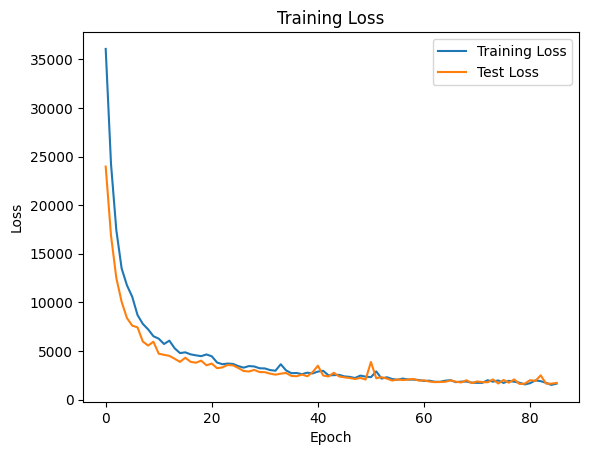

In [25]:
#Plot loss history

#Start useful when Test loss not calculated at every epoch (testinverval > 1)
start = 0 

losses = np.array(losses)
test_losses = np.array(test_losses)
plt.plot(losses[start:], label='Training Loss')
xtest = np.array(range(len(test_losses))) * test_interval
plt.plot(xtest[start:], test_losses[start:], label='Test Loss')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

In [26]:
#Load batch for plotting
count = 0
for testbatch in test_loader:
    count += 1
    if count == 1:
        break
len(testbatch)

64

C:\Users\bshul\AppData\Local\Temp\ipykernel_54156\2606502980.py:34: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  batch.x[:,:xdimnormalize] = batch.x[:,:xdimnormalize].cpu() * inv_std + inv_mean
C:\Users\bshul\AppData\Local\Temp\ipykernel_54156\2606502980.py:35: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  batch.y = batch.y.cpu() * out_std + out_mean
C:\Users\bshul\AppData\Local\Temp\ipykernel_54156\2606502980.py:36: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  pred = pred.cpu() * out_std + out_mean


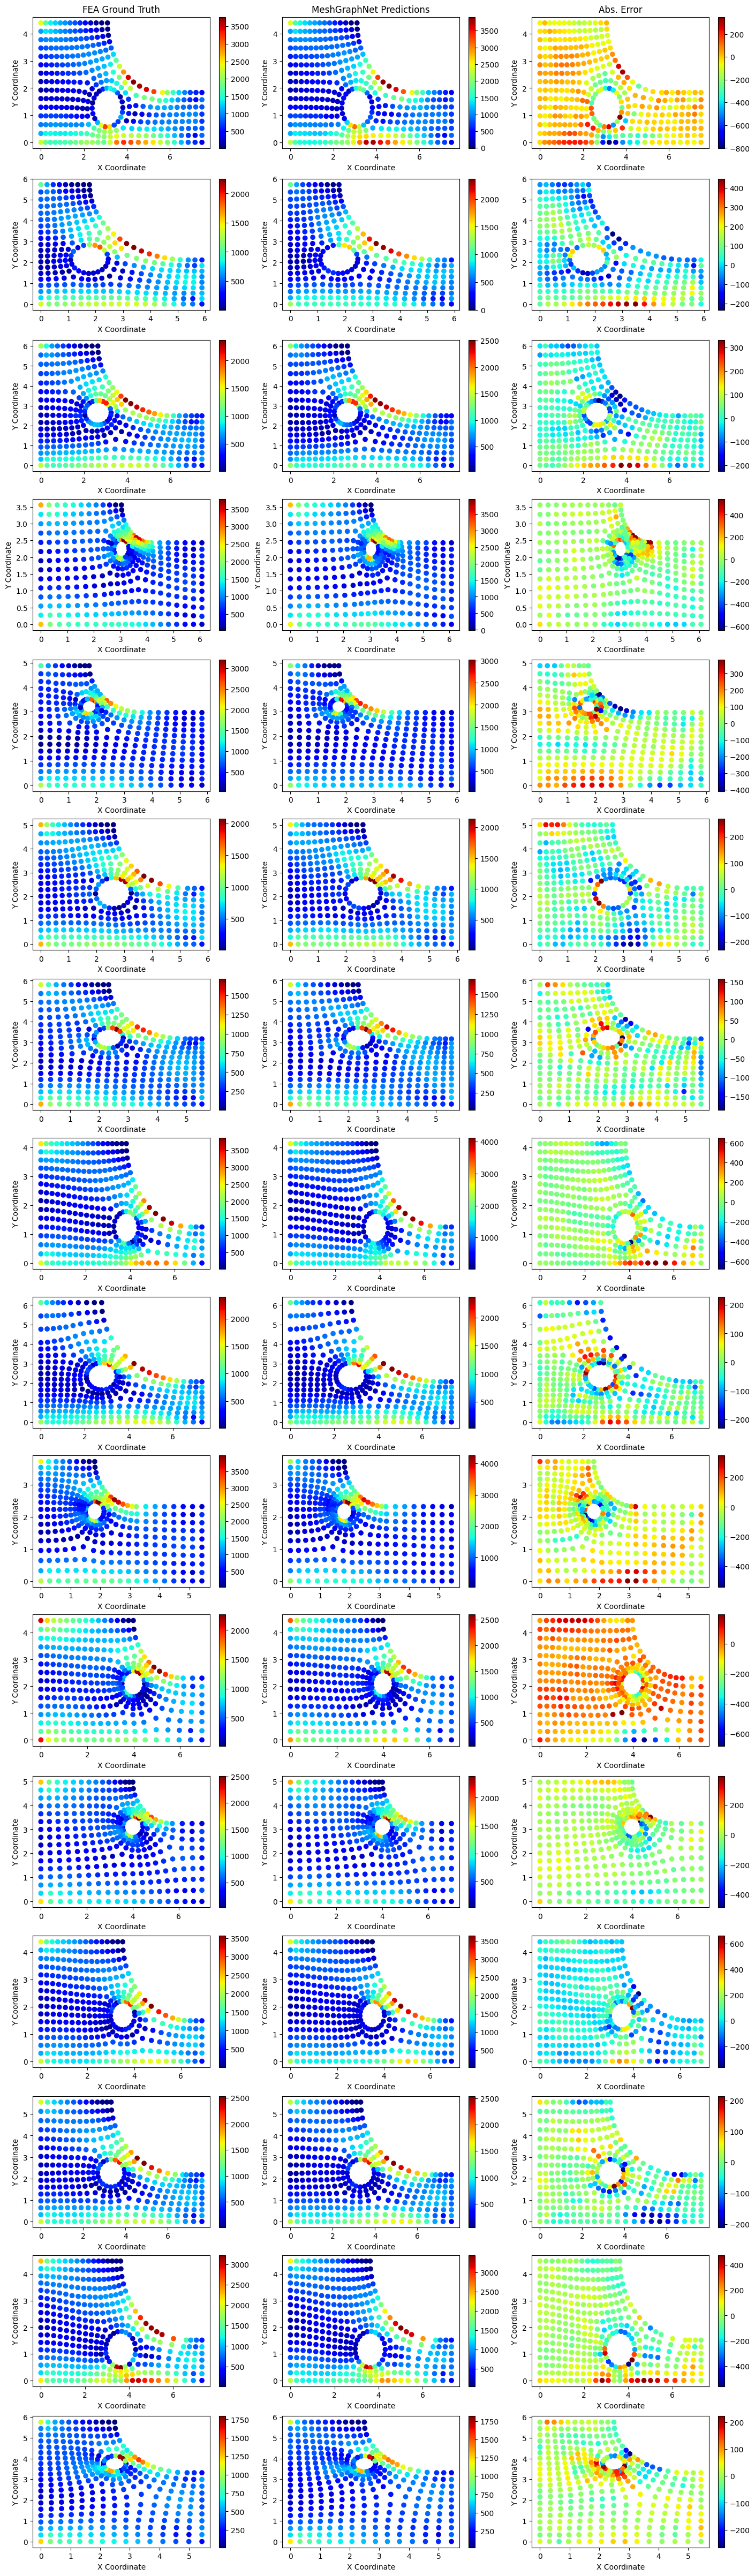

In [27]:
#Plotting
plot_error = True

if plot_error:
    height = 3
    ncols = 3
else:
    height = 4
    ncols = 2

#Set up plots
#Optional error column
#16 rows unless testbatch is smaller
fig, axs = plt.subplots(min(16,len(testbatch)), ncols, figsize=(14, min(16,len(testbatch))*height), layout='constrained')

#Output value to plot
vidx = -1

for i in range(min(16, len(testbatch))):
    #single model
    batch = testbatch[i]

    batch.x = batch.x.to(device)
    batch.edge_attr = batch.edge_attr.to(device)
    batch.edge_index = batch.edge_index.to(device)
    batch.y = batch.y.to(device)

    #predict
    with torch.no_grad():
        pred = bestmodel(batch)

    #Inverse scale
    if standardize:
        batch.x[:,:xdimnormalize] = batch.x[:,:xdimnormalize].cpu() * inv_std + inv_mean
        batch.y = batch.y.cpu() * out_std + out_mean
        pred = pred.cpu() * out_std + out_mean 

    #Ground Truth
    im0 = axs[i,0].scatter(batch.x[:,0].cpu().detach(), batch.x[:,1].cpu().detach(), c=batch.y[:,vidx].cpu().detach(), cmap=cm.jet)
    axs[i,0].set_xlabel('X Coordinate')
    axs[i,0].set_ylabel('Y Coordinate')
    if i == 0: axs[i,0].set_title('FEA Ground Truth')
    fig.colorbar(im0, ax=axs[i,0])

    #Predictions
    im1 = axs[i,1].scatter(batch.x[:,0].cpu().detach(), batch.x[:,1].cpu().detach(), c=pred[:,vidx].cpu().detach(), cmap=cm.jet)
    axs[i,1].set_xlabel('X Coordinate')
    axs[i,1].set_ylabel('Y Coordinate')
    if i == 0: axs[i,1].set_title('MeshGraphNet Predictions')
    fig.colorbar(im1, ax=axs[i,1])   

    #Error
    if plot_error:
        error = batch.y[:,vidx].cpu().detach() -pred[:,vidx].cpu().detach()
        im2 = axs[i,2].scatter(batch.x[:,0].cpu().detach(), batch.x[:,1].cpu().detach(), c=error, cmap=cm.jet)
        axs[i,2].set_xlabel('X Coordinate')
        axs[i,2].set_ylabel('Y Coordinate')
        if i == 0: axs[i,2].set_title('Abs. Error')
        fig.colorbar(im2, ax=axs[i,2])          
    